In [2]:
from sklearn.metrics import r2_score
from scipy.stats import gaussian_kde 
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import r2_score
import xarray as xr

#select particular representative gauge
reg = 'CT'

if reg == 'CT':
    columnname = str(38)
    mask_size = '892'
elif reg == 'SR':
    columnname = str(54)
    mask_size = '961'

MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
SimDir = "/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/"

#read all events 
event_list = np.loadtxt('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/events/sample_events53550.txt',dtype='str')

list_size = ['529','892','1658','3454','7071']  
task = 'sigmaMC'
train_size = list_size[3]


Sample Predictions(Mean) 500

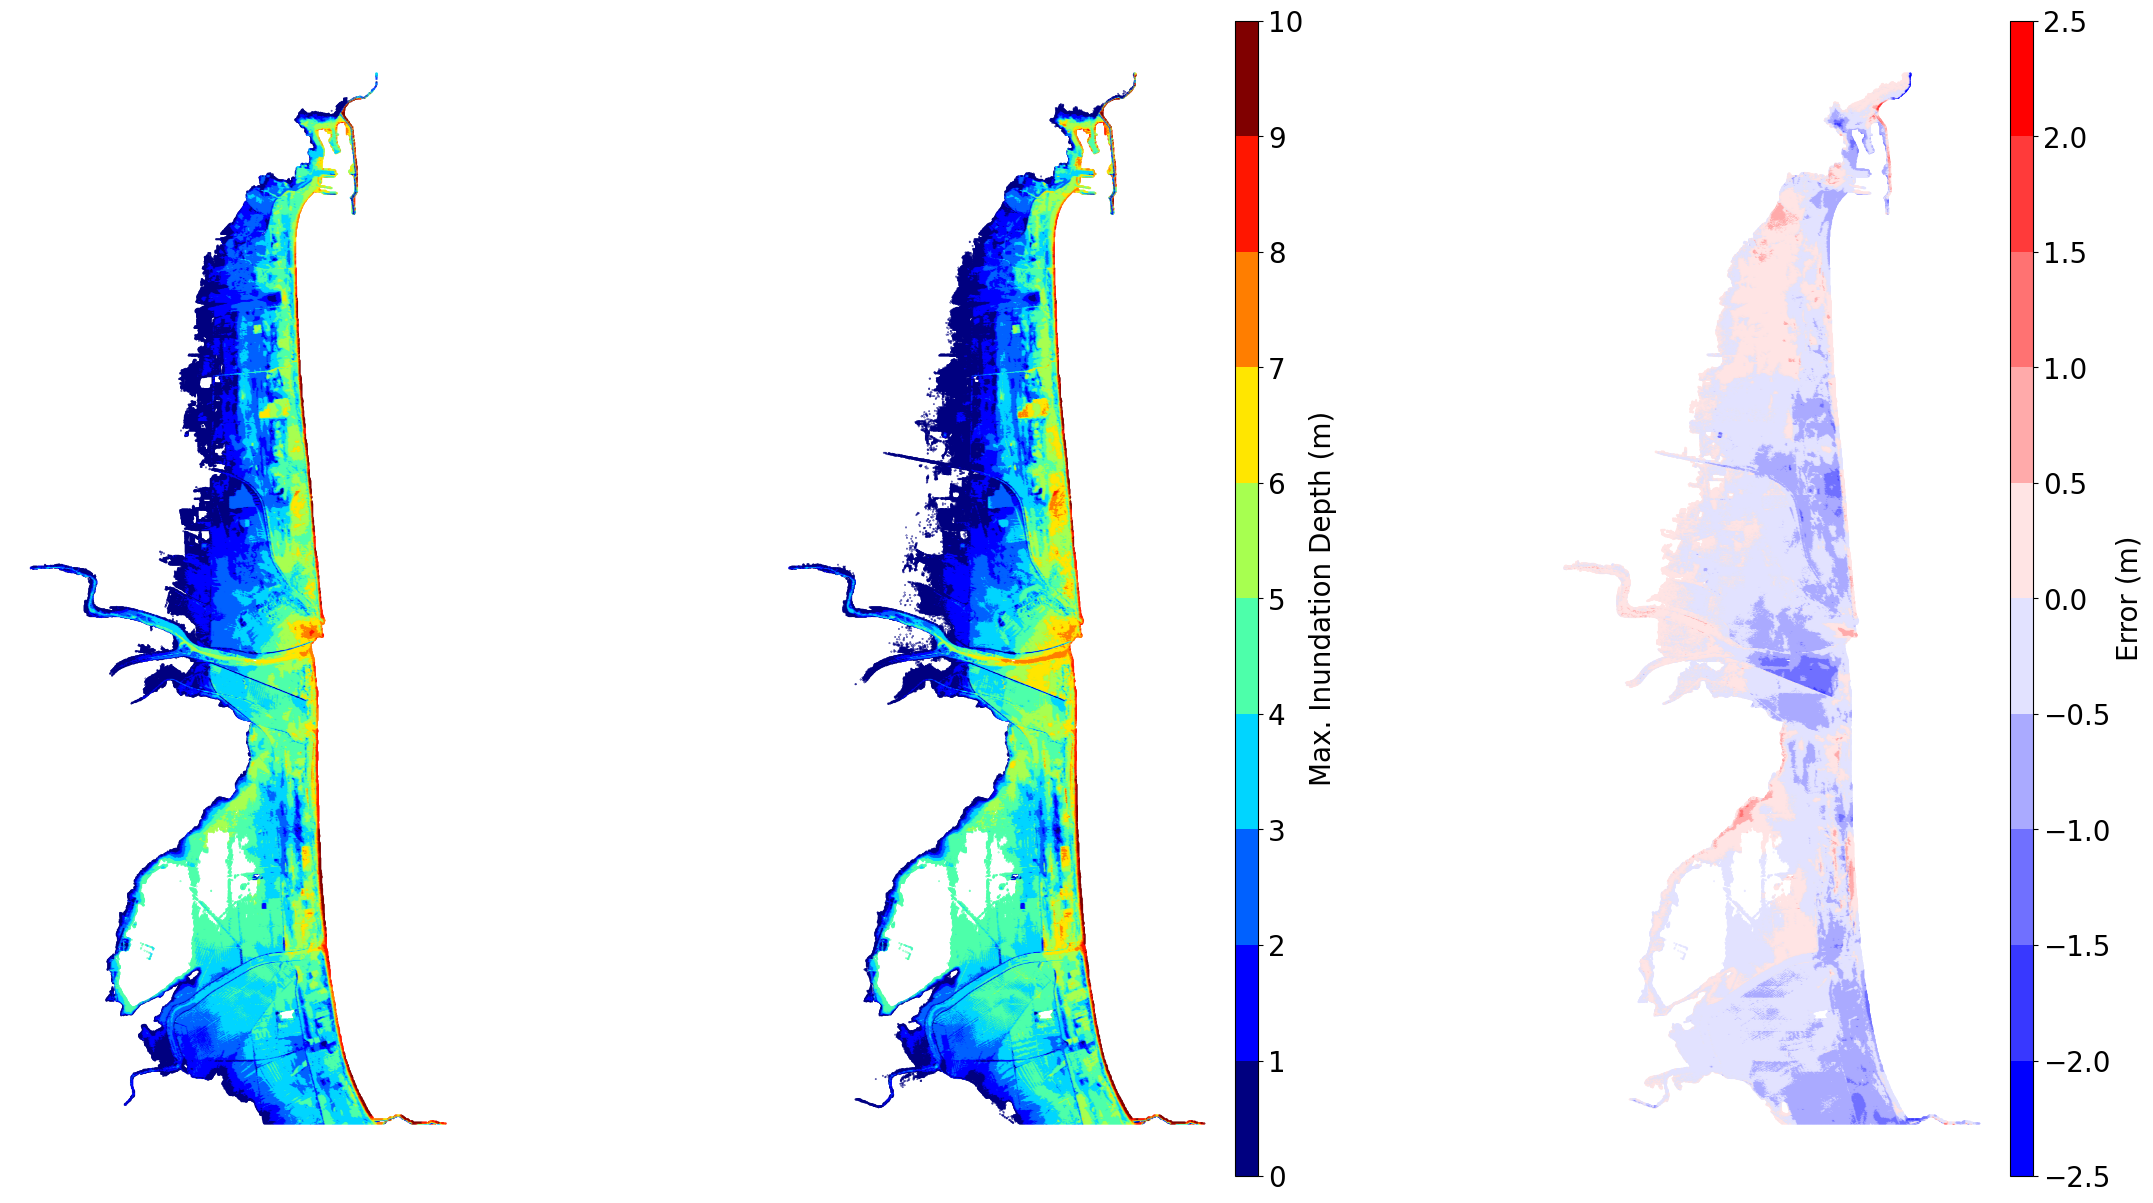

In [13]:
# from mpl_toolkits.axes_grid1 import make_axes_locatable
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.colors import BoundaryNorm
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# import xarray as xr

# # Select particular representative gauge
# test_size = 3
# idx = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/lat_lon_idx_{reg}_{mask_size}.npy')
# n_eve = len(np.loadtxt(f'{MLDir}/data/events/shuffled_events_test_{reg}_{test_size}.txt', dtype='str'))
# nflood_grids = len(idx)
# red_d_array = np.memmap(f'{MLDir}/data/processed/dflat_{reg}_{test_size}.dat', mode='r', dtype=float, shape=(n_eve, nflood_grids))

# id = 7750
# eve_id = np.loadtxt(f'{MLDir}/data/events/shuffled_events_test_{reg}_{test_size}.txt', dtype='str')[id]

# data2plot = xr.open_dataset(f'{SimDir}/{eve_id}/{reg}_deformation.nc')
# dz = data2plot['deformation'].values

# x = np.linspace(0, dz.shape[1], dz.shape[1])
# y = np.linspace(0, dz.shape[0], dz.shape[0])
# xy_mesh = np.meshgrid(x, y)
# x_list, y_list = xy_mesh[0].flatten(), xy_mesh[1].flatten()
# dz_list = dz.flatten()

# true = red_d_array[id, :]
# pred = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/{task}/out/pred_trainsize{train_size}_testsize{test_size}_direct.npy')[id, :]
# pred[np.isnan(pred)] = 0
# error = true - pred

# del red_d_array

# red_dZ_array = np.memmap(f'{MLDir}/data/processed/dZflat_{reg}_{test_size}.dat', mode='r', dtype=float, shape=(n_eve, nflood_grids))
# deform = red_dZ_array[id, :]
# del red_dZ_array

# idx = np.c_[idx, true, pred, error, deform]
# idx[idx[:, 4] < 0.1, 4] = np.nan
# idx[idx[:, 5] < 0.1, 5] = np.nan

# minval, maxval = 0, 10
# minerror, maxerror = -2.5, 2.5
# num_bins = 10

# bounds = np.linspace(minval, maxval, num_bins + 1)
# norm = BoundaryNorm(bounds, ncolors=plt.cm.jet.N, clip=True)
# error_bounds = np.linspace(minerror, maxerror, num_bins + 1)
# error_norm = BoundaryNorm(error_bounds, ncolors=plt.cm.bwr.N, clip=True)

fig, axs = plt.subplots(1, 3, figsize=(30, 15))

sc1 = axs[0].scatter(idx[:, 1], idx[:, 0], c=idx[:, 4], s=0.1, cmap='jet', norm=norm)
# axs[0].text(200, 2200, 'True', fontsize=30)
axs[0].set_aspect('equal')
axs[0].set_axis_off()

sc2 = axs[1].scatter(idx[:, 1], idx[:, 0], c=idx[:, 5], s=0.1, cmap='jet', norm=norm)
# axs[1].text(200, 2200, 'Prediction', fontsize=30)
axs[1].set_aspect('equal')
axs[1].set_axis_off()

sc3 = axs[2].scatter(idx[:, 1], idx[:, 0], c=idx[:, 6], s=0.1, cmap='bwr', norm=error_norm)
# axs[2].text(200, 2200, 'Error', fontsize=30)
axs[2].set_aspect('equal')
axs[2].set_axis_off()

# sc4 = axs[3].scatter(x_list, y_list, c=dz_list, cmap='bwr', norm=error_norm)
# axs[3].text(300, 2200, 'dZ', fontsize=20)
# axs[3].set_xlim(min(idx[:, 1]), max(idx[:, 1]))
# axs[3].set_ylim(min(idx[:, 0]), max(idx[:, 0]))
# axs[3].set_aspect('equal')
# axs[3].set_axis_off()

divider2 = make_axes_locatable(axs[1])
cax2 = divider2.append_axes('right', size='5%', pad=0.1)
cbar1 = plt.colorbar(sc1, cax=cax2, orientation='vertical', label='Max. Inundation Depth (m)', ticks=bounds)
cbar1.set_label('Max. Inundation Depth (m)', fontsize=20)
cbar1.ax.tick_params(labelsize=20)

divider3 = make_axes_locatable(axs[2])
cax3 = divider3.append_axes('right', size='5%', pad=0.1)
cbar2 = plt.colorbar(sc3, cax=cax3, orientation='vertical', label='Error (m)', ticks=error_bounds)
cbar2.set_label('Error (m)', fontsize=20)
cbar2.ax.tick_params(labelsize=20)

# divider1 = make_axes_locatable(axs[3])
# cax1 = divider1.append_axes('right', size='5%', pad=0.1)
# cbar3 = plt.colorbar(sc4, cax=cax1, orientation='vertical', label='dZ (m)', ticks=error_bounds)
# cbar3.set_label('dZ (m)', fontsize=20)
# cbar3.ax.tick_params(labelsize=20)

plt.subplots_adjust(wspace=0, hspace=0)
# plt.show()
#make background transparent
# fig.patch.set_alpha(0.0)
fig.savefig(f'sample.png', dpi=300, bbox_inches='tight', transparent=True)


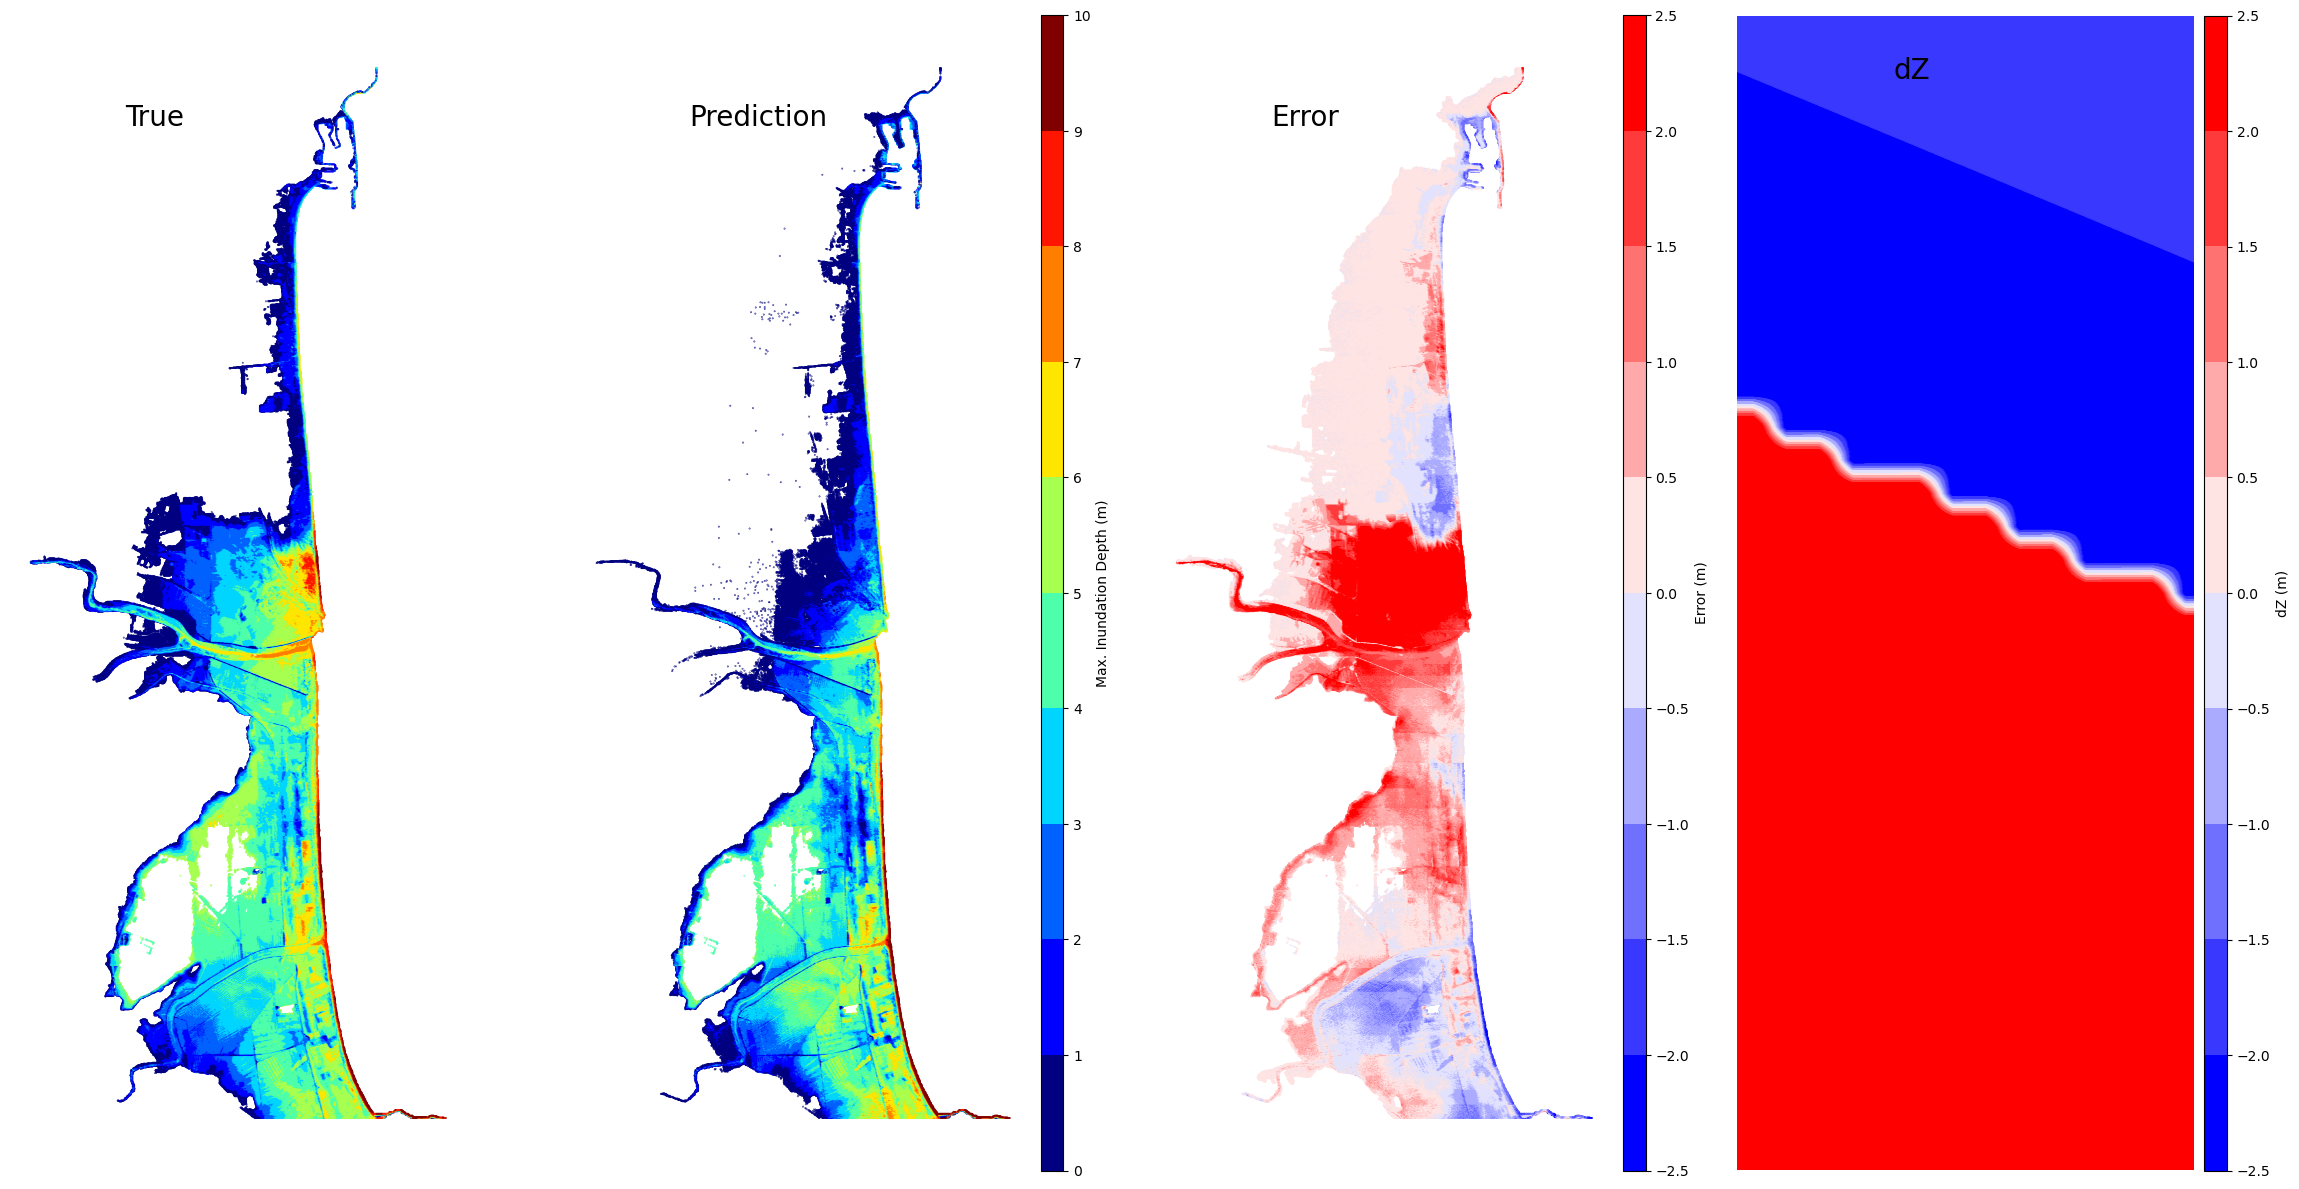

In [3]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import xarray as xr

# Select particular representative gauge
test_size = 2
idx= np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/lat_lon_idx_{reg}_{mask_size}.npy')
#add recon and true column to to the idx array
n_eve = len(np.loadtxt(f'{MLDir}/data/events/shuffled_events_test_{reg}_{test_size}.txt', dtype='str'))
nflood_grids = len(idx)
red_d_array = np.memmap(f'{MLDir}/data/processed/dflat_{reg}_{test_size}.dat',
                        mode='r',
                        dtype=float,
                        shape=(n_eve, nflood_grids))

id = 9970 #BS_manning003/E01267N3753E01646N3535-BS-M809_E01502N3737_D010_S112D70R270_A006995_S075
eve_id = np.loadtxt(f'{MLDir}/data/events/shuffled_events_test_{reg}_{test_size}.txt', dtype='str')[id]

data2plot = xr.open_dataset(f'{SimDir}/{eve_id}/{reg}_deformation.nc')
dz = data2plot['deformation'].values

x = np.linspace(0, dz.shape[1], dz.shape[1])
y = np.linspace(0, dz.shape[0], dz.shape[0])
xy_mesh = np.meshgrid(x, y)
x_list, y_list = xy_mesh[0].flatten(), xy_mesh[1].flatten()
dz_list = dz.flatten()

true = red_d_array[id, :]
pred = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/{task}/out/pred_trainsize{train_size}_testsize{test_size}_direct.npy')[id, :]
pred[np.isnan(pred)] = 0
error = true - pred

del red_d_array

red_dZ_array = np.memmap(f'{MLDir}/data/processed/dZflat_{reg}_{test_size}.dat', mode='r', dtype=float, shape=(n_eve, nflood_grids))
deform = red_dZ_array[id, :]
del red_dZ_array

idx = np.c_[idx, true, pred, error, deform]
idx[idx[:, 4] < 0.1, 4] = np.nan
idx[idx[:, 5] < 0.1, 5] = np.nan

minval, maxval = 0, 10
minerror, maxerror = -2.5, 2.5
num_bins = 10

bounds = np.linspace(minval, maxval, num_bins + 1)
norm = BoundaryNorm(bounds, ncolors=plt.cm.jet.N, clip=True)
error_bounds = np.linspace(minerror, maxerror, num_bins + 1)
error_norm = BoundaryNorm(error_bounds, ncolors=plt.cm.bwr.N, clip=True)

fig, axs = plt.subplots(1, 4, figsize=(30, 15))

sc1 = axs[0].scatter(idx[:, 1], idx[:, 0], c=idx[:, 4], s=0.1, cmap='jet', norm=norm)
axs[0].text(200, 2100, 'True', fontsize=20)
axs[0].set_aspect('equal')
axs[0].set_axis_off()

sc2 = axs[1].scatter(idx[:, 1], idx[:, 0], c=idx[:, 5], s=0.1, cmap='jet', norm=norm)
axs[1].text(200, 2100, 'Prediction', fontsize=20)
axs[1].set_aspect('equal')
axs[1].set_axis_off()

sc3 = axs[2].scatter(idx[:, 1], idx[:, 0], c=idx[:, 6], s=0.1, cmap='bwr', norm=error_norm)
axs[2].text(200, 2100, 'Error', fontsize=20)
axs[2].set_aspect('equal')
axs[2].set_axis_off()

sc4 = axs[3].scatter(x_list, y_list, c=dz_list, cmap='bwr', norm=error_norm)
axs[3].text(300, 2100, 'dZ', fontsize=20)
axs[3].set_xlim(min(idx[:, 1]), max(idx[:, 1]))
axs[3].set_ylim(min(idx[:, 0]), max(idx[:, 0]))
axs[3].set_aspect('equal')
axs[3].set_axis_off()

divider2 = make_axes_locatable(axs[1])
cax2 = divider2.append_axes('right', size='5%', pad=0.1)
plt.colorbar(sc1, cax=cax2, orientation='vertical', label='Max. Inundation Depth (m)', ticks=bounds)

divider3 = make_axes_locatable(axs[2])
cax3 = divider3.append_axes('right', size='5%', pad=0.1)
plt.colorbar(sc3, cax=cax3, orientation='vertical', label='Error (m)', ticks=error_bounds)

divider1 = make_axes_locatable(axs[3])
cax1 = divider1.append_axes('right', size='5%', pad=0.1)
plt.colorbar(sc4, cax=cax1, orientation='vertical', label='dZ (m)', ticks=error_bounds)

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()


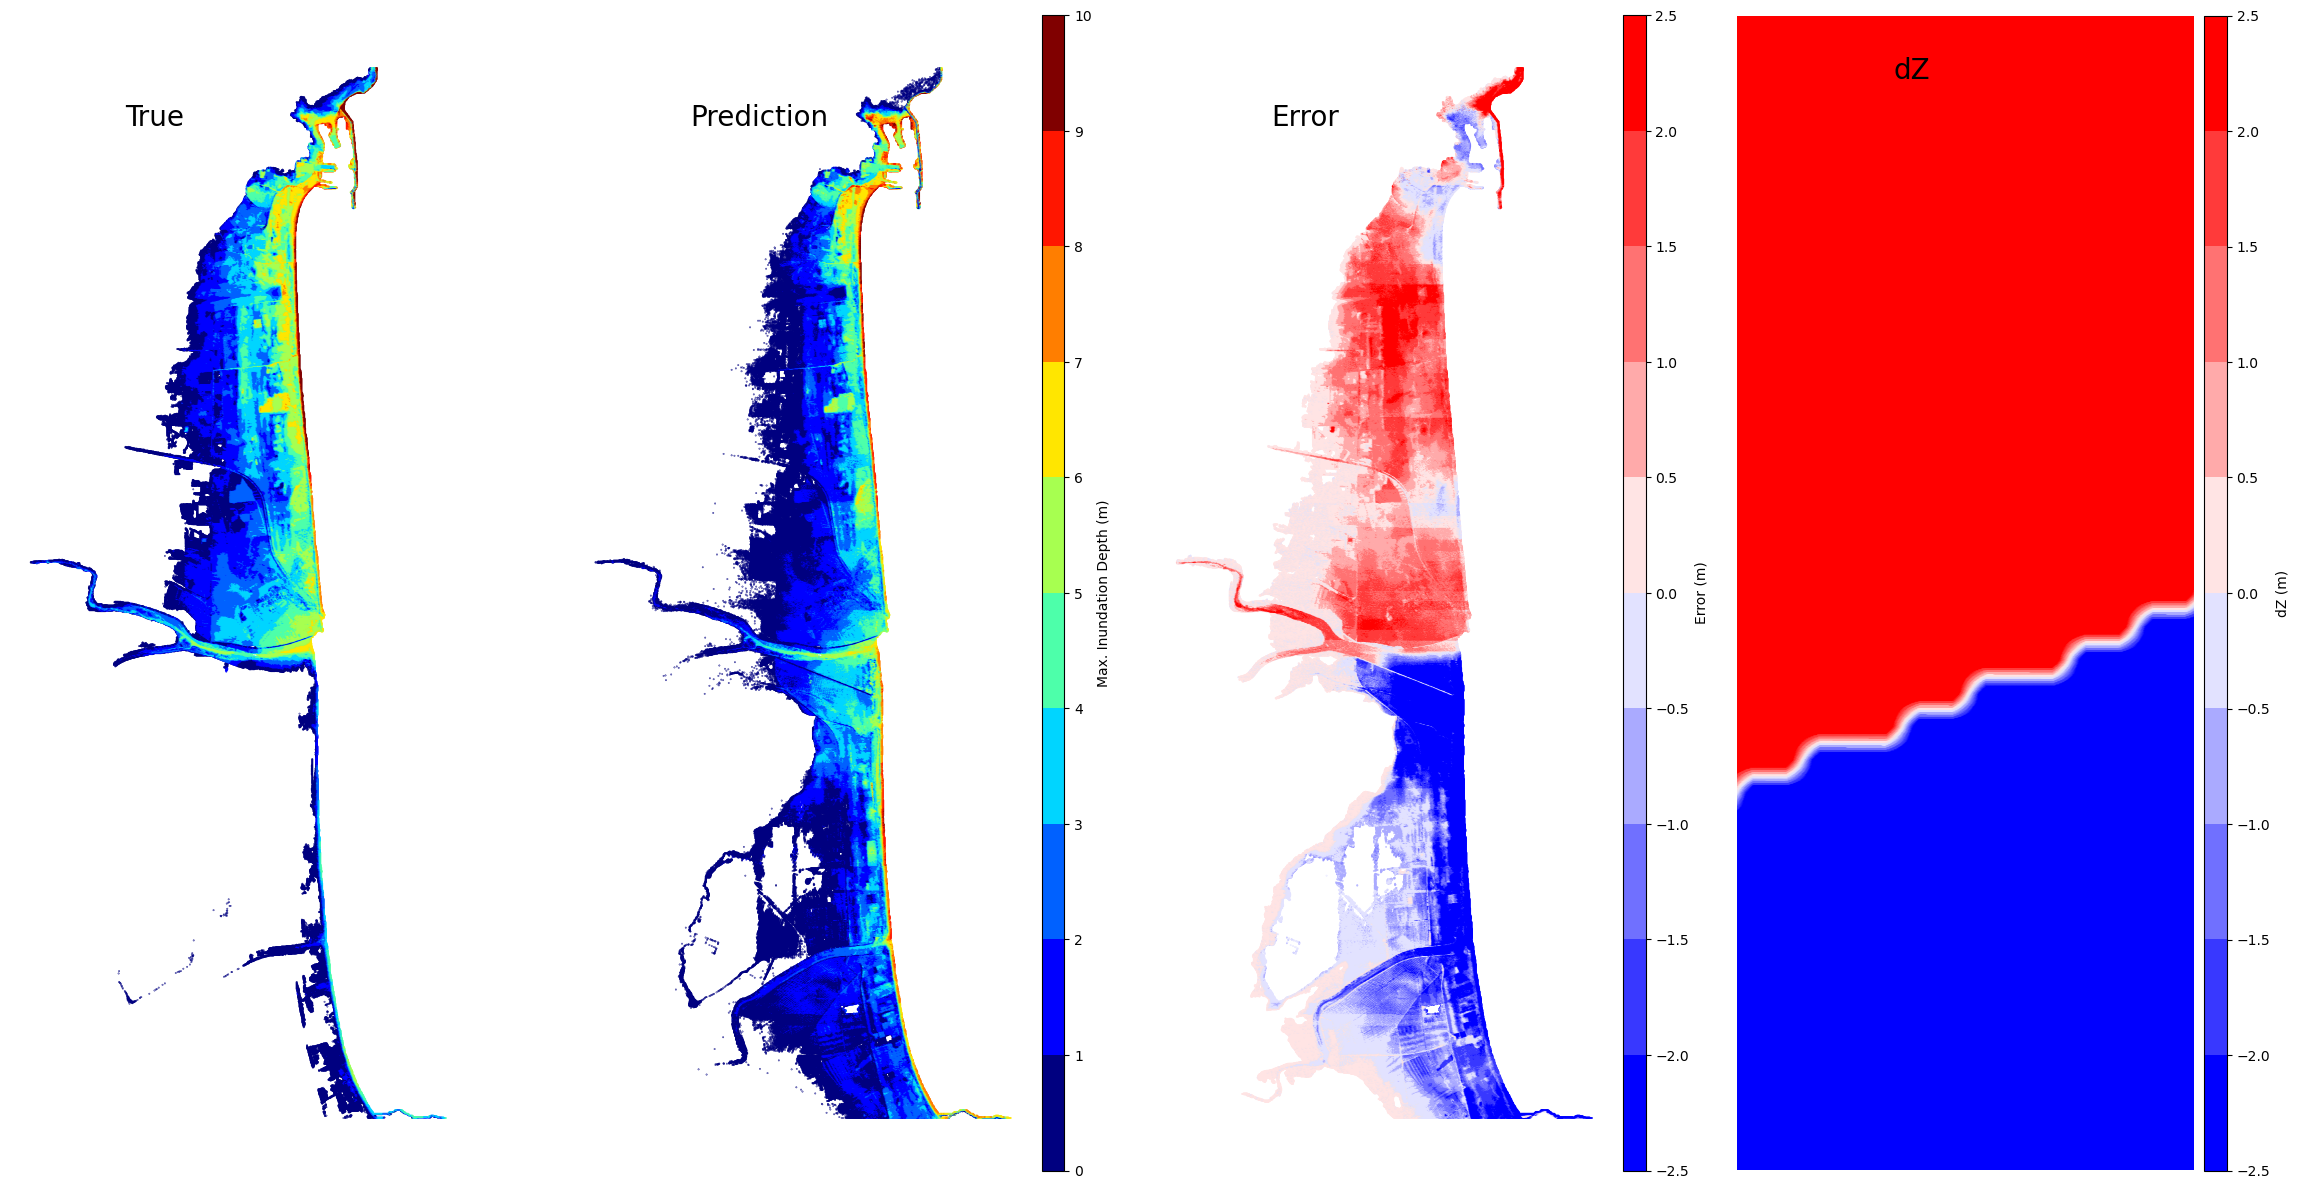

In [2]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import xarray as xr

# Select particular representative gauge
test_size = 3
idx = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/lat_lon_idx_{reg}_{mask_size}.npy')
n_eve = len(np.loadtxt(f'{MLDir}/data/events/shuffled_events_test_{reg}_{test_size}.txt', dtype='str'))
nflood_grids = len(idx)
red_d_array = np.memmap(f'{MLDir}/data/processed/dflat_{reg}_{test_size}.dat', mode='r', dtype=float, shape=(n_eve, nflood_grids))

id = 10520
eve_id = np.loadtxt(f'{MLDir}/data/events/shuffled_events_test_{reg}_{test_size}.txt', dtype='str')[id]

data2plot = xr.open_dataset(f'{SimDir}/{eve_id}/{reg}_deformation.nc')
dz = data2plot['deformation'].values

x = np.linspace(0, dz.shape[1], dz.shape[1])
y = np.linspace(0, dz.shape[0], dz.shape[0])
xy_mesh = np.meshgrid(x, y)
x_list, y_list = xy_mesh[0].flatten(), xy_mesh[1].flatten()
dz_list = dz.flatten()

true = red_d_array[id, :]
pred = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/{task}/out/pred_trainsize{train_size}_testsize{test_size}_direct.npy')[id, :]
pred[np.isnan(pred)] = 0
error = true - pred

del red_d_array

red_dZ_array = np.memmap(f'{MLDir}/data/processed/dZflat_{reg}_{test_size}.dat', mode='r', dtype=float, shape=(n_eve, nflood_grids))
deform = red_dZ_array[id, :]
del red_dZ_array

idx = np.c_[idx, true, pred, error, deform]
idx[idx[:, 4] < 0.1, 4] = np.nan
idx[idx[:, 5] < 0.1, 5] = np.nan

minval, maxval = 0, 10
minerror, maxerror = -2.5, 2.5
num_bins = 10

bounds = np.linspace(minval, maxval, num_bins + 1)
norm = BoundaryNorm(bounds, ncolors=plt.cm.jet.N, clip=True)
error_bounds = np.linspace(minerror, maxerror, num_bins + 1)
error_norm = BoundaryNorm(error_bounds, ncolors=plt.cm.bwr.N, clip=True)

fig, axs = plt.subplots(1, 4, figsize=(30, 15))

sc1 = axs[0].scatter(idx[:, 1], idx[:, 0], c=idx[:, 4], s=0.1, cmap='jet', norm=norm)
axs[0].text(200, 2100, 'True', fontsize=20)
axs[0].set_aspect('equal')
axs[0].set_axis_off()

sc2 = axs[1].scatter(idx[:, 1], idx[:, 0], c=idx[:, 5], s=0.1, cmap='jet', norm=norm)
axs[1].text(200, 2100, 'Prediction', fontsize=20)
axs[1].set_aspect('equal')
axs[1].set_axis_off()

sc3 = axs[2].scatter(idx[:, 1], idx[:, 0], c=idx[:, 6], s=0.1, cmap='bwr', norm=error_norm)
axs[2].text(200, 2100, 'Error', fontsize=20)
axs[2].set_aspect('equal')
axs[2].set_axis_off()

sc4 = axs[3].scatter(x_list, y_list, c=dz_list, cmap='bwr', norm=error_norm)
axs[3].text(300, 2100, 'dZ', fontsize=20)
axs[3].set_xlim(min(idx[:, 1]), max(idx[:, 1]))
axs[3].set_ylim(min(idx[:, 0]), max(idx[:, 0]))
axs[3].set_aspect('equal')
axs[3].set_axis_off()

divider2 = make_axes_locatable(axs[1])
cax2 = divider2.append_axes('right', size='5%', pad=0.1)
plt.colorbar(sc1, cax=cax2, orientation='vertical', label='Max. Inundation Depth (m)', ticks=bounds)

divider3 = make_axes_locatable(axs[2])
cax3 = divider3.append_axes('right', size='5%', pad=0.1)
plt.colorbar(sc3, cax=cax3, orientation='vertical', label='Error (m)', ticks=error_bounds)

divider1 = make_axes_locatable(axs[3])
cax1 = divider1.append_axes('right', size='5%', pad=0.1)
plt.colorbar(sc4, cax=cax1, orientation='vertical', label='dZ (m)', ticks=error_bounds)

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()


1500 events

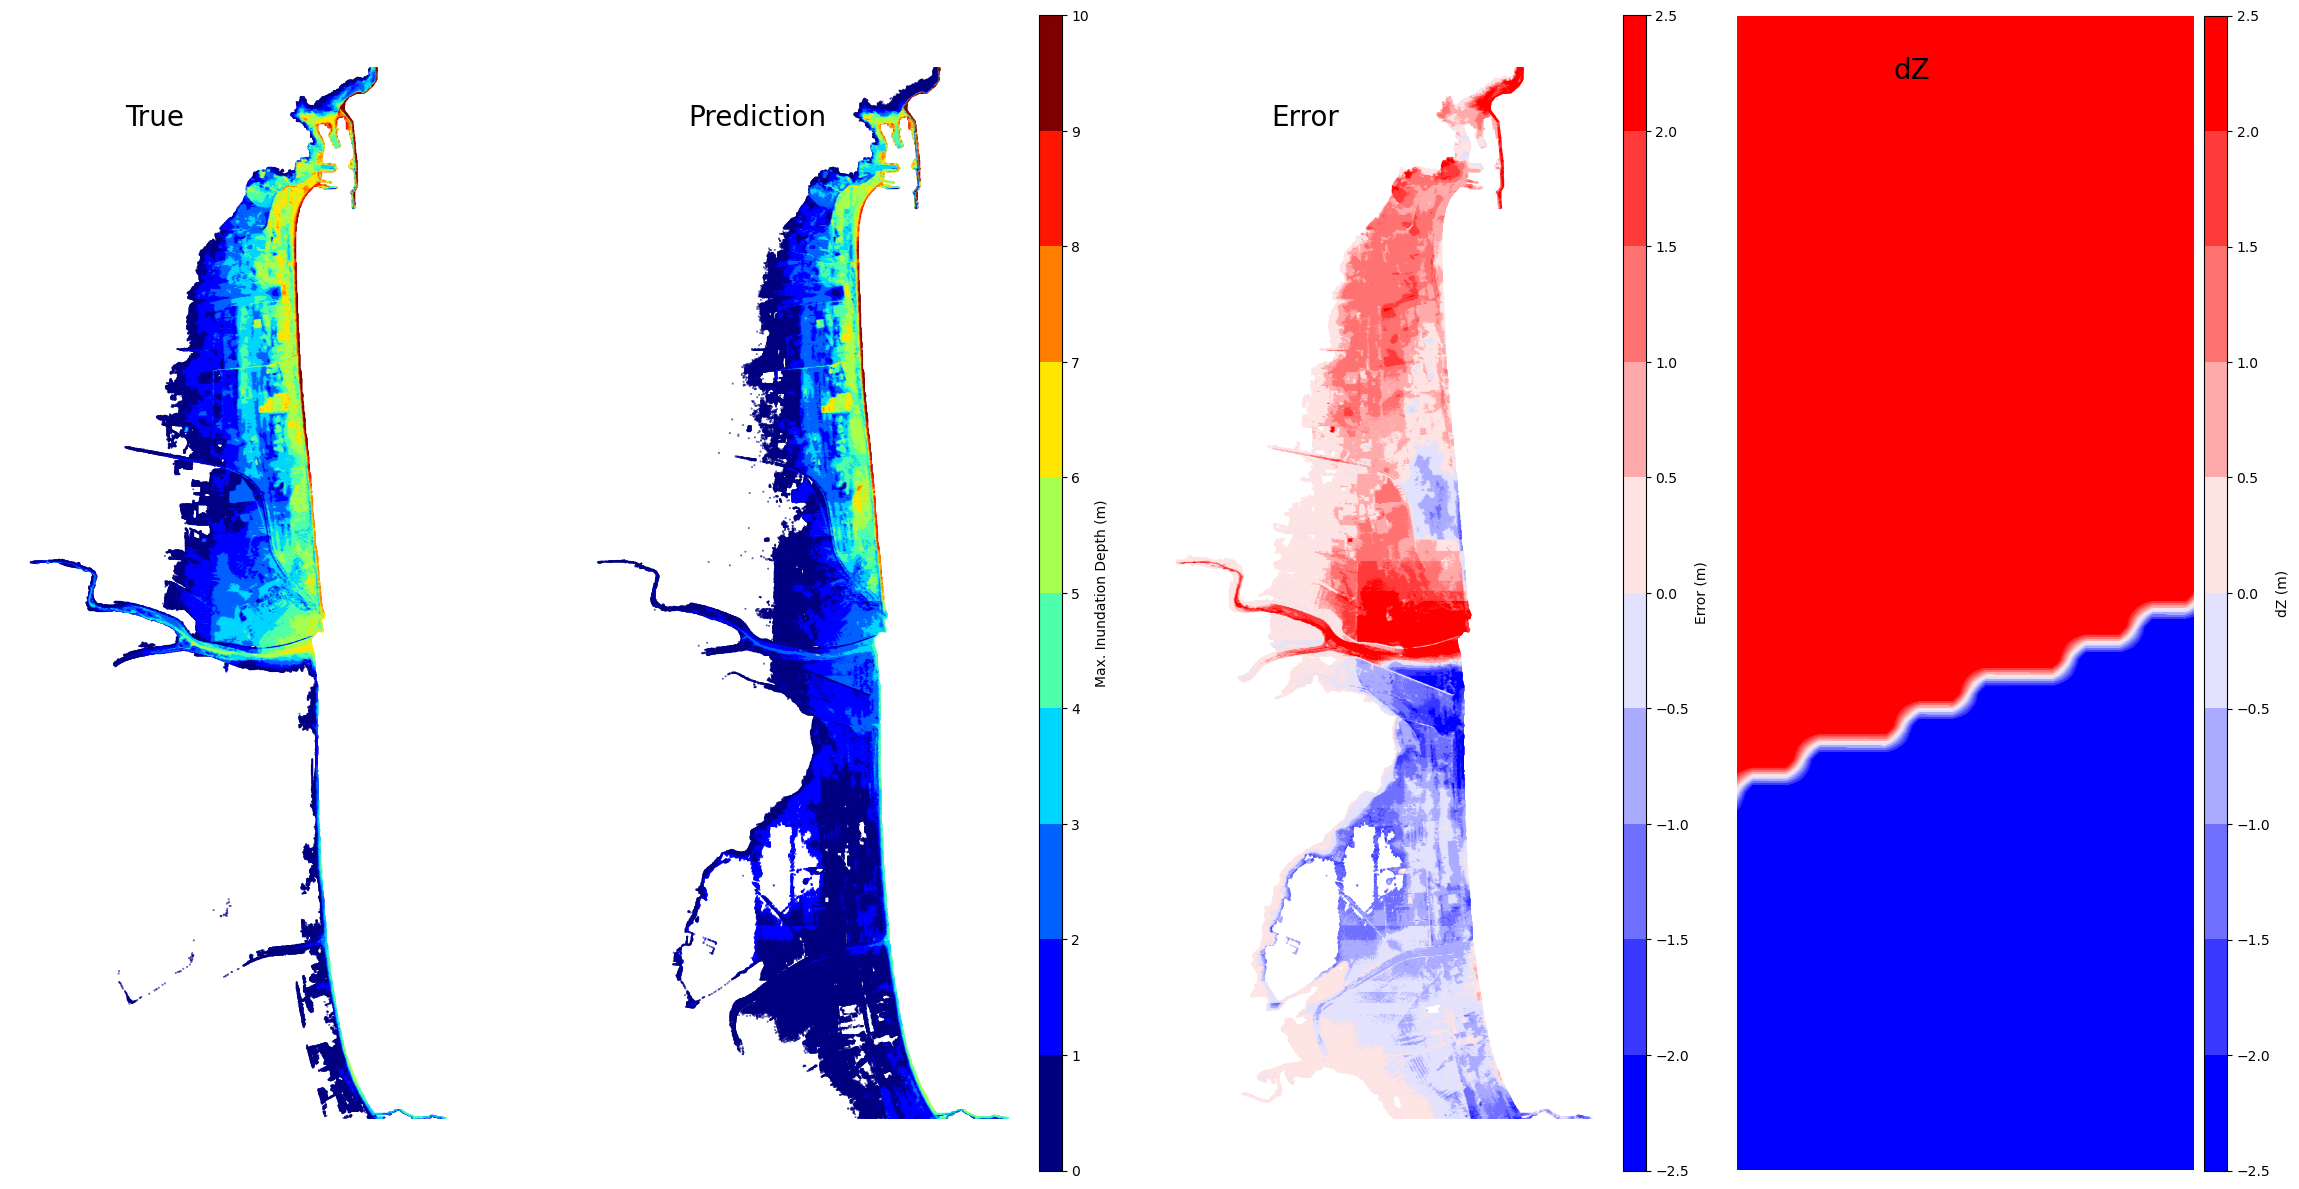

In [3]:
train_size = list_size[2]
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import xarray as xr

# Select particular representative gauge
test_size = 3
idx = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/lat_lon_idx_{reg}_{mask_size}.npy')
n_eve = len(np.loadtxt(f'{MLDir}/data/events/shuffled_events_test_{reg}_{test_size}.txt', dtype='str'))
nflood_grids = len(idx)
red_d_array = np.memmap(f'{MLDir}/data/processed/dflat_{reg}_{test_size}.dat', mode='r', dtype=float, shape=(n_eve, nflood_grids))

id = 10520
eve_id = np.loadtxt(f'{MLDir}/data/events/shuffled_events_test_{reg}_{test_size}.txt', dtype='str')[id]

data2plot = xr.open_dataset(f'{SimDir}/{eve_id}/{reg}_deformation.nc')
dz = data2plot['deformation'].values

x = np.linspace(0, dz.shape[1], dz.shape[1])
y = np.linspace(0, dz.shape[0], dz.shape[0])
xy_mesh = np.meshgrid(x, y)
x_list, y_list = xy_mesh[0].flatten(), xy_mesh[1].flatten()
dz_list = dz.flatten()

true = red_d_array[id, :]
pred = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/{task}/out/pred_trainsize{train_size}_testsize{test_size}_direct.npy')[id, :]
pred[np.isnan(pred)] = 0
error = true - pred

del red_d_array

red_dZ_array = np.memmap(f'{MLDir}/data/processed/dZflat_{reg}_{test_size}.dat', mode='r', dtype=float, shape=(n_eve, nflood_grids))
deform = red_dZ_array[id, :]
del red_dZ_array

idx = np.c_[idx, true, pred, error, deform]
idx[idx[:, 4] < 0.1, 4] = np.nan
idx[idx[:, 5] < 0.1, 5] = np.nan

minval, maxval = 0, 10
minerror, maxerror = -2.5, 2.5
num_bins = 10

bounds = np.linspace(minval, maxval, num_bins + 1)
norm = BoundaryNorm(bounds, ncolors=plt.cm.jet.N, clip=True)
error_bounds = np.linspace(minerror, maxerror, num_bins + 1)
error_norm = BoundaryNorm(error_bounds, ncolors=plt.cm.bwr.N, clip=True)

fig, axs = plt.subplots(1, 4, figsize=(30, 15))

sc1 = axs[0].scatter(idx[:, 1], idx[:, 0], c=idx[:, 4], s=0.1, cmap='jet', norm=norm)
axs[0].text(200, 2100, 'True', fontsize=20)
axs[0].set_aspect('equal')
axs[0].set_axis_off()

sc2 = axs[1].scatter(idx[:, 1], idx[:, 0], c=idx[:, 5], s=0.1, cmap='jet', norm=norm)
axs[1].text(200, 2100, 'Prediction', fontsize=20)
axs[1].set_aspect('equal')
axs[1].set_axis_off()

sc3 = axs[2].scatter(idx[:, 1], idx[:, 0], c=idx[:, 6], s=0.1, cmap='bwr', norm=error_norm)
axs[2].text(200, 2100, 'Error', fontsize=20)
axs[2].set_aspect('equal')
axs[2].set_axis_off()

sc4 = axs[3].scatter(x_list, y_list, c=dz_list, cmap='bwr', norm=error_norm)
axs[3].text(300, 2100, 'dZ', fontsize=20)
axs[3].set_xlim(min(idx[:, 1]), max(idx[:, 1]))
axs[3].set_ylim(min(idx[:, 0]), max(idx[:, 0]))
axs[3].set_aspect('equal')
axs[3].set_axis_off()

divider2 = make_axes_locatable(axs[1])
cax2 = divider2.append_axes('right', size='5%', pad=0.1)
plt.colorbar(sc1, cax=cax2, orientation='vertical', label='Max. Inundation Depth (m)', ticks=bounds)

divider3 = make_axes_locatable(axs[2])
cax3 = divider3.append_axes('right', size='5%', pad=0.1)
plt.colorbar(sc3, cax=cax3, orientation='vertical', label='Error (m)', ticks=error_bounds)

divider1 = make_axes_locatable(axs[3])
cax1 = divider1.append_axes('right', size='5%', pad=0.1)
plt.colorbar(sc4, cax=cax1, orientation='vertical', label='dZ (m)', ticks=error_bounds)

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()


3500 events